# Visualize Leakage

In [ ]:
using Piccolo
using Random
Random.seed!(42)

# Create a 3-level transmon
sys = TransmonSystem(levels = 3, δ = 0.2, drive_bounds = [0.4, 0.4])

# Define X gate in computational subspace
U_goal = EmbeddedOperator(:X, sys)

size(U_goal.operator)

# From symbol (gate name)
U_X = EmbeddedOperator(:X, sys)
U_H = EmbeddedOperator(:H, sys)

# From matrix
custom_gate = ComplexF64[1 0; 0 exp(im * π / 4)]  # T gate
U_T = EmbeddedOperator(custom_gate, sys)
#leak_indices = get_iso_vec_leakage_indices(U_goal)

opts = PiccoloOptions(
    leakage_cost = 10.0,
    leakage_constraint = true,
    leakage_constraint_value = 1e-3,
    display = :silent,
)


PiccoloOptions(:silent, false, ExponentialAction.expv, true, false, nothing, 1.0, true, false, true, 0.001, 10.0)

In [3]:
# 1. Create multilevel system
sys = TransmonSystem(levels = 3, δ = 0.2, drive_bounds = [0.15, 0.15])

# 2. Define embedded gate
U_goal = EmbeddedOperator(:X, sys)

# 3. Create trajectory
T, N = 20.0, 100
times = collect(range(0, T, length = N))
pulse = ZeroOrderPulse(0.05 * randn(2, N), times)
qtraj = UnitaryTrajectory(sys, pulse, U_goal)

# 4. Configure leakage suppression
opts = PiccoloOptions(
    leakage_cost = 5.0,
    leakage_constraint = true,
    leakage_constraint_value = 1e-3,
    display = :silent,
)

# 5. Solve
qcp = SmoothPulseProblem(qtraj, N; Q = 100.0, piccolo_options = opts)
solve!(
    qcp;
    max_iter = 150,
    verbose = false,
    print_level = 1,
    eval_hessian = false
)

fidelity(qcp)


0.7473505853357505

In [4]:
traj = get_trajectory(qcp)
leak_indices = get_iso_vec_leakage_indices(U_goal)

# Leakage objective (soft penalty)
leak_obj = LeakageObjective(leak_indices, :Ũ⃗, traj; Qs = fill(10.0, N))

# Leakage constraint (hard bound)
leak_constraint = LeakageConstraint(1e-3, leak_indices, :Ũ⃗, traj)


NonlinearKnotPointConstraint on [:Ũ⃗], inequality, 100 times (g_dim = 8)

In [7]:
T_warm = 10.0
times_warm = collect(range(0, T_warm, length = N))
pulse_warm = ZeroOrderPulse(0.05 * randn(2, N), times_warm)
qtraj_warm = UnitaryTrajectory(sys, pulse_warm, U_goal)

# Step 1: Optimize without leakage constraints
opts_initial = PiccoloOptions(timesteps_all_equal = true, display = :silent)
qcp_initial =
    SmoothPulseProblem(qtraj_warm, N; Q = 100.0, R = 1e-3, piccolo_options = opts_initial)
solve!(qcp_initial; max_iter = 100, print_level = 1, eval_hessian = false)
fidelity(qcp_initial)


0.9999999559056747

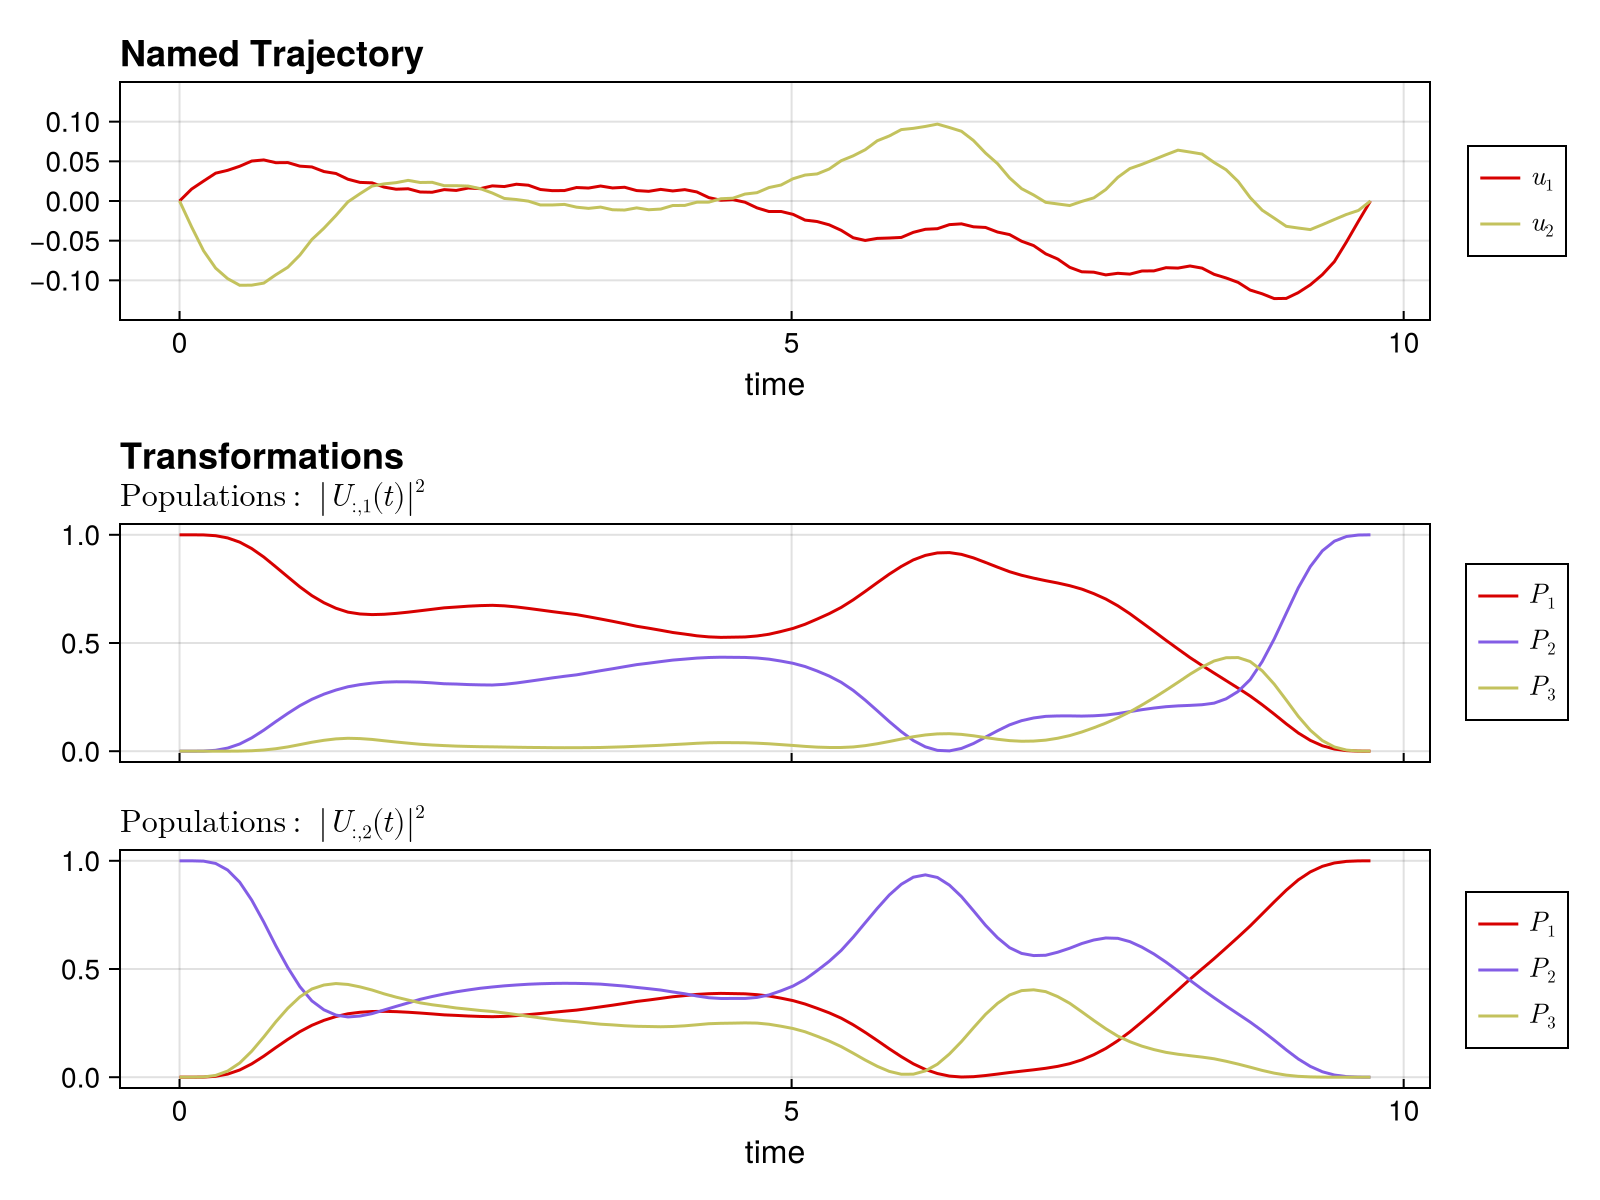

In [8]:
using CairoMakie
plot_unitary_populations(get_trajectory(qcp_initial))


# Minimizing leakage using traditional DRAG Method

# Finding better optimal control plumbing methods 